### Pacotes importados

In [6]:
using LinearAlgebra
using Printf
using Plots

## Chapter 8: Quasi-Newton methods

### Algorithm 8.1: Finite difference Newton's method: one variable

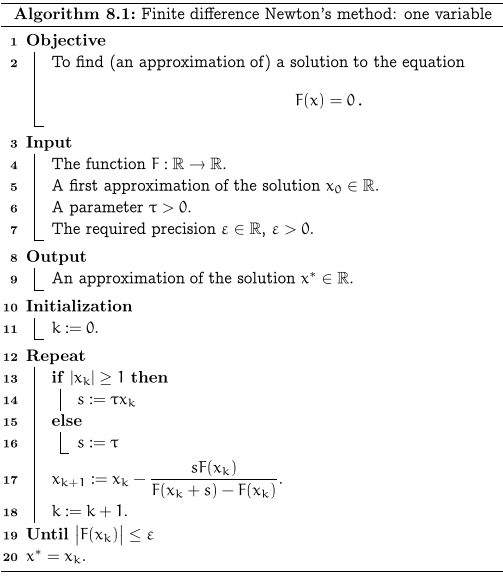

Example: $F(x)=x^2-2$. Run the example with $x_0=2$ and $\tau=10^{-7}$

  k                x_k             F(x_k)                  s
  0  +2.0000000000E+00  +2.0000000000E+00  +2.0000000000E-07
  1  +1.5000000253E+00  +2.5000007582E-01  +1.5000000253E-07
  2  +1.4166666722E+00  +6.9444602354E-03  +1.4166666722E-07
  3  +1.4142156864E+00  +6.0076824644E-06  +1.4142156864E-07
  4  +1.4142135624E+00  +4.8108184103E-12  +1.4142135624E-07
  5  +1.4142135624E+00  +4.4408920985E-16  +1.4142135624E-07

Solução aproximada:
x* = 1.4142135623730951
F(x*) = 4.440892098500626e-16
|F(x*)| = 4.440892098500626e-16


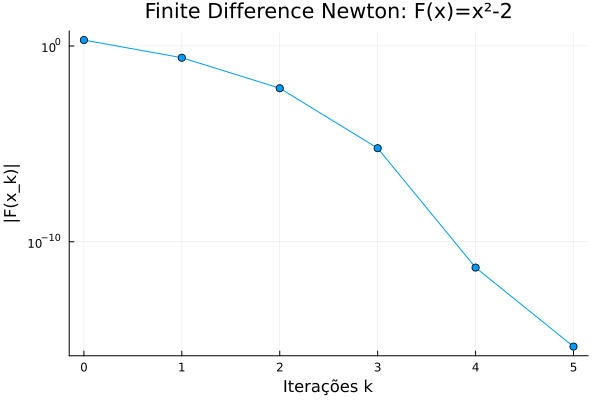

In [2]:
F(x) = x^2 - 2

x = 2.0
tau = 1e-7
epsilon = 1e-15
k = 0
maxiter = 50

ks = Int[]
fxs = Float64[]

@printf("%3s %18s %18s %18s\n", "k", "x_k", "F(x_k)", "s")

while k <= maxiter
    fx = F(x)

    if abs(x) >= 1
        s = tau * x
    else
        s = tau
    end

    push!(ks, k)
    push!(fxs, abs(fx))

    @printf("%3d %+18.10E %+18.10E %+18.10E\n", k, x, fx, s)

    if abs(fx) <= epsilon
        break
    end

    x = x - (s * fx) / (F(x + s) - F(x))

    k += 1
end

println("\nSolução aproximada:")
println("x* = ", x)
println("F(x*) = ", F(x))
println("|F(x*)| = ", abs(F(x)))

plot(
    ks,
    fxs,
    marker = :circle,
    xlabel = "Iterações k",
    ylabel = "|F(x_k)|",
    title = "Finite Difference Newton: F(x)=x²-2",
    legend = false,
    yscale = :log10
)

Run the example with $x_0=2$ and $\tau=0.1$

  k                x_k             F(x_k)                  s
  0  +2.0000000000E+00  +2.0000000000E+00  +2.0000000000E-01
  1  +1.5238095238E+00  +3.2199546485E-01  +1.5238095238E-01
  2  +1.4231859410E+00  +2.5458222783E-02  +1.4231859410E-01
  3  +1.4146677546E+00  +1.2848558238E-03  +1.4146677546E-01
  4  +1.4142352600E+00  +6.1370662199E-05  +1.4142352600E-01
  5  +1.4142145958E+00  +2.9228394971E-06  +1.4142145958E-01
  6  +1.4142136116E+00  +1.3918380182E-07  +1.4142136116E-01
  7  +1.4142135647E+00  +6.6278018629E-09  +1.4142135647E-01
  8  +1.4142135625E+00  +3.1560976055E-10  +1.4142135625E-01
  9  +1.4142135624E+00  +1.5028422951E-11  +1.4142135624E-01
 10  +1.4142135624E+00  +7.1542771707E-13  +1.4142135624E-01
 11  +1.4142135624E+00  +3.4194869158E-14  +1.4142135624E-01
 12  +1.4142135624E+00  +1.3322676296E-15  +1.4142135624E-01
 13  +1.4142135624E+00  +4.4408920985E-16  +1.4142135624E-01

Solução aproximada:
x* = 1.4142135623730951
F(x*) = 4.440892098500626e-16
|F(x*)| = 

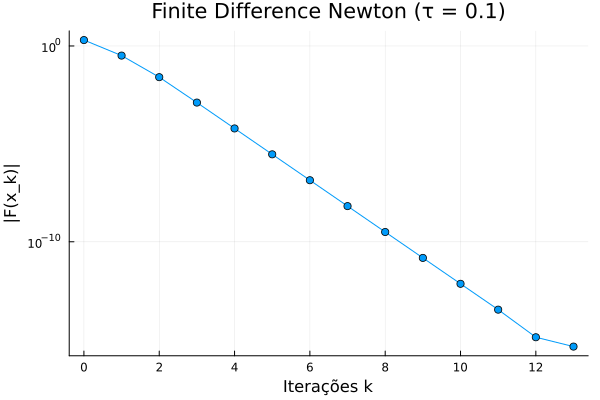

In [3]:
F(x) = x^2 - 2

x = 2.0
tau = 0.1
epsilon = 1e-15
k = 0
maxiter = 50

ks = Int[]
fxs = Float64[]

@printf("%3s %18s %18s %18s\n", "k", "x_k", "F(x_k)", "s")

while k <= maxiter
    fx = F(x)

    if abs(x) >= 1
        s = tau * x
    else
        s = tau
    end

    push!(ks, k)
    push!(fxs, abs(fx))

    @printf("%3d %+18.10E %+18.10E %+18.10E\n", k, x, fx, s)

    if abs(fx) <= epsilon
        break
    end

    x = x - (s * fx) / (F(x + s) - F(x))

    k += 1
end

println("\nSolução aproximada:")
println("x* = ", x)
println("F(x*) = ", F(x))
println("|F(x*)| = ", abs(F(x)))

plot(
    ks,
    fxs,
    marker = :circle,
    xlabel = "Iterações k",
    ylabel = "|F(x_k)|",
    title = "Finite Difference Newton (τ = 0.1)",
    legend = false,
    yscale = :log10
)

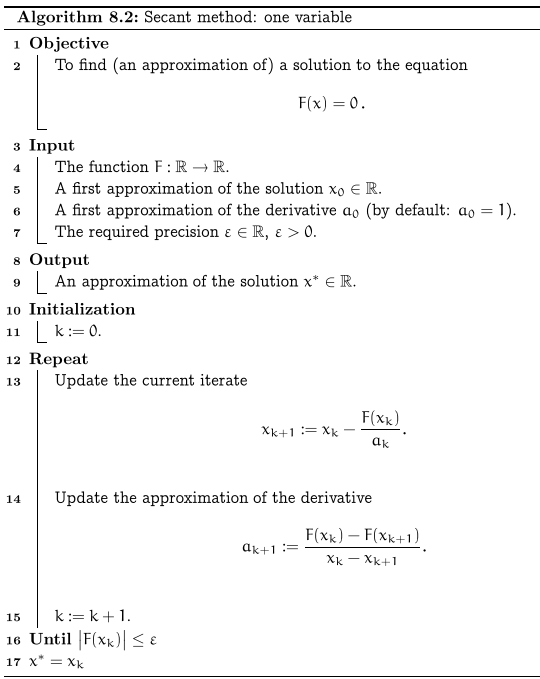

Example: $F(x)=x^2-2$, with $x_0=2$ and $a_0=1$

  k                x_k             F(x_k)                a_k
  0  +2.0000000000E+00  +2.0000000000E+00  +1.0000000000E+00
  1  +0.0000000000E+00  -2.0000000000E+00  +2.0000000000E+00
  2  +1.0000000000E+00  -1.0000000000E+00  +1.0000000000E+00
  3  +2.0000000000E+00  +2.0000000000E+00  +3.0000000000E+00
  4  +1.3333333333E+00  -2.2222222222E-01  +3.3333333333E+00
  5  +1.4000000000E+00  -4.0000000000E-02  +2.7333333333E+00
  6  +1.4146341463E+00  +1.1897679952E-03  +2.8146341463E+00
  7  +1.4142114385E+00  -6.0072868389E-06  +2.8288455848E+00
  8  +1.4142135621E+00  -8.9314555751E-10  +2.8284250006E+00
  9  +1.4142135624E+00  +8.8817841970E-16  +2.8284270570E+00

Solução aproximada:
x* = 1.4142135623730954
F(x*) = 8.881784197001252e-16
|F(x*)| = 8.881784197001252e-16


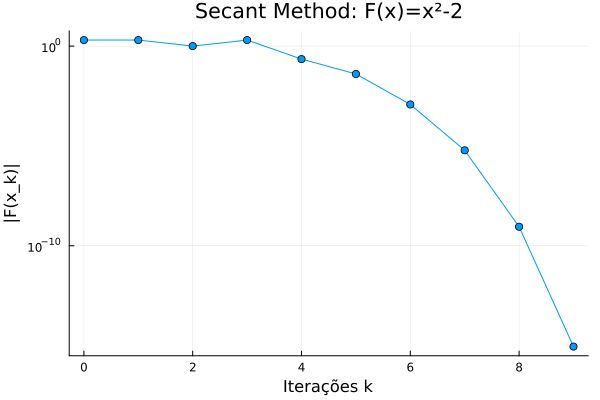

In [4]:
F(x) = x^2 - 2

x = 2.0
a = 1.0
epsilon = 1e-15
k = 0
maxiter = 50

ks = Int[]
fxs = Float64[]

@printf("%3s %18s %18s %18s\n", "k", "x_k", "F(x_k)", "a_k")

while k <= maxiter
    fx = F(x)

    push!(ks, k)
    push!(fxs, abs(fx))

    @printf("%3d %+18.10E %+18.10E %+18.10E\n", k, x, fx, a)

    if abs(fx) <= epsilon
        break
    end

    # Atualiza x_{k+1}
    x_new = x - fx / a

    # Atualiza a_{k+1}
    a_new = (F(x) - F(x_new)) / (x - x_new)

    x = x_new
    a = a_new
    k += 1
end

println("\nSolução aproximada:")
println("x* = ", x)
println("F(x*) = ", F(x))
println("|F(x*)| = ", abs(F(x)))

plot(
    ks,
    fxs,
    marker = :circle,
    xlabel = "Iterações k",
    ylabel = "|F(x_k)|",
    title = "Secant Method: F(x)=x²-2",
    legend = false,
    yscale = :log10
)

### Algorithm 8.3: finite difference Newton's method: $n$ variables

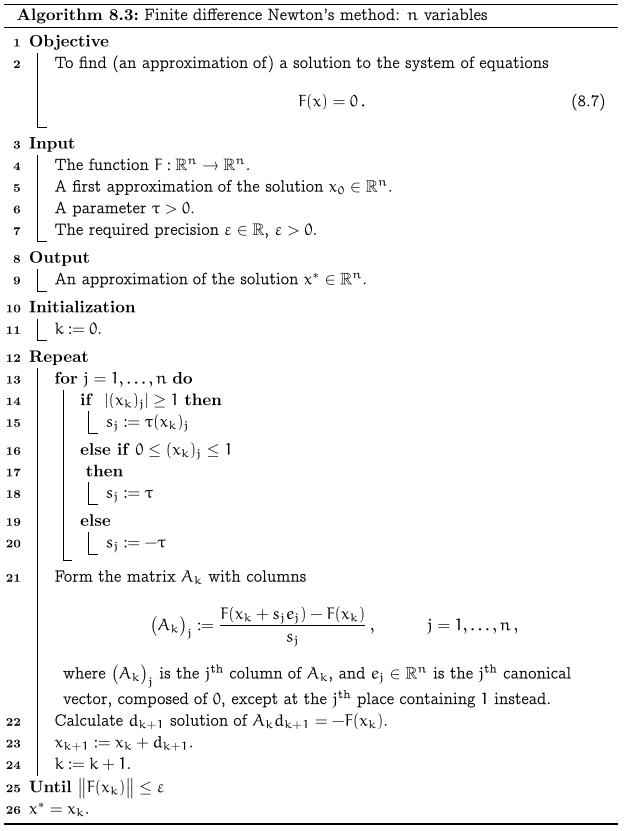

Example: $F(x)=\left(\begin{array}{c}(x_1+1)^2+ x_2^2 - 2 \\ e^{x_1} + x_2^3 - 2 \end{array}\right)$. Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\tau=10^{-7}$

  k                 x1                 x2           ||F(x)||
  0  +1.0000000000E+00  +1.0000000000E+00  +3.4572376895E+00
  1  +1.5235922841E-01  +1.1952815793E+00  +1.1547087761E+00
  2  -1.0837685001E-02  +1.0361111886E+00  +1.1404263173E-01
  3  -8.8966783288E-04  +1.0015353225E+00  +3.9423456114E-03
  4  -1.3701692951E-06  +1.0000029389E+00  +8.0806136493E-06
  5  -5.6881158808E-12  +1.0000000000E+00  +2.9863924459E-11
  6  -1.1083265290E-16  +1.0000000000E+00  +4.4408920985E-16

Solução aproximada:
x* = [-1.1083265290474262e-16, 1.0000000000000002]
F(x*) = [0.0, 4.440892098500626e-16]
||F(x*)|| = 4.440892098500626e-16


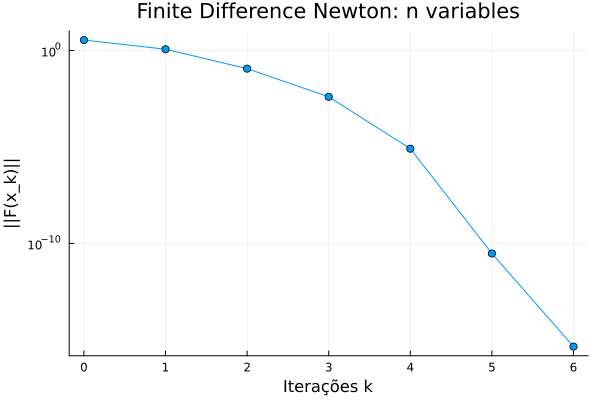

In [8]:
F(x) = [
    (x[1] + 1)^2 + x[2]^2 - 2
    exp(x[1]) + x[2]^3 - 2
]

function finite_difference_jacobian(F, x, tau)
    n = length(x)
    A = zeros(n, n)
    Fx = F(x)

    for j in 1:n
        if abs(x[j]) >= 1
            sj = tau * x[j]
        elseif 0 <= x[j] <= 1
            sj = tau
        else
            sj = -tau
        end

        e = zeros(n)
        e[j] = 1.0

        A[:, j] = (F(x + sj * e) - Fx) / sj
    end

    return A
end

x = [1.0, 1.0]
tau = 1e-7
epsilon = 1e-15
k = 0
maxiter = 50

ks = Int[]
norms = Float64[]

@printf("%3s %18s %18s %18s\n", "k", "x1", "x2", "||F(x)||")

while k <= maxiter
    Fx = F(x)
    normFx = norm(Fx)

    push!(ks, k)
    push!(norms, max(normFx, 1e-16))

    @printf("%3d %+18.10E %+18.10E %+18.10E\n", k, x[1], x[2], normFx)

    if normFx <= epsilon
        break
    end

    A = finite_difference_jacobian(F, x, tau)

    d = A \ (-Fx)

    x = x + d
    k += 1
end

println("\nSolução aproximada:")
println("x* = ", x)
println("F(x*) = ", F(x))
println("||F(x*)|| = ", norm(F(x)))

plot(
    ks,
    norms,
    marker = :circle,
    xlabel = "Iterações k",
    ylabel = "||F(x_k)||",
    title = "Finite Difference Newton: n variables",
    legend = false,
    yscale = :log10
)

Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\tau=0.1$

  k                 x1                 x2           ||F(x)||
  0  +1.0000000000E+00  +1.0000000000E+00  +3.4572376895E+00
  1  +1.6462965929E-01  +1.2023897128E+00  +1.2185277812E+00
  2  -1.4574108338E-02  +1.0571349920E+00  +1.8897289752E-01
  3  -5.7235630096E-03  +1.0097667847E+00  +2.5253622800E-02
  4  -4.7689636012E-04  +1.0012201625E+00  +3.5184272507E-03
  5  -6.6507824125E-05  +1.0001416711E+00  +3.8881423591E-04
  6  -7.0228456773E-06  +1.0000162772E+00  +4.5723191163E-05
  7  -8.3864962942E-07  +1.0000018684E+00  +5.1925631370E-06
  8  -9.4511262954E-08  +1.0000002144E+00  +5.9886500005E-07
  9  -1.0938463316E-08  +1.0000000246E+00  +6.8570382944E-08
 10  -1.2504223443E-09  +1.0000000028E+00  +7.8775910138E-09
 11  -1.4376120757E-10  +1.0000000003E+00  +9.0360536040E-10
 12  -1.6484451897E-11  +1.0000000000E+00  +1.0372309043E-10
 13  -1.8926108212E-12  +1.0000000000E+00  +1.1902272920E-11
 14  -2.1727753384E-13  +1.0000000000E+00  +1.3659179227E-12
 15  -2.5039034533E-14  

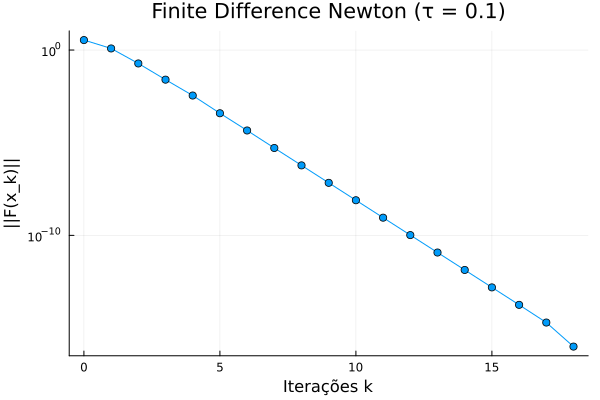

In [9]:
# Função
F(x) = [
    (x[1] + 1)^2 + x[2]^2 - 2
    exp(x[1]) + x[2]^3 - 2
]

# Jacobiana por diferenças finitas
function finite_difference_jacobian(F, x, tau)
    n = length(x)
    A = zeros(n, n)
    Fx = F(x)

    for j in 1:n
        if abs(x[j]) >= 1
            sj = tau * x[j]
        elseif 0 <= x[j] <= 1
            sj = tau
        else
            sj = -tau
        end

        e = zeros(n)
        e[j] = 1.0

        A[:, j] = (F(x + sj * e) - Fx) / sj
    end

    return A
end

# Dados iniciais
x = [1.0, 1.0]
tau = 0.1
epsilon = 1e-15
k = 0
maxiter = 50

ks = Int[]
norms = Float64[]

@printf("%3s %18s %18s %18s\n", "k", "x1", "x2", "||F(x)||")

while k <= maxiter
    Fx = F(x)
    normFx = norm(Fx)

    push!(ks, k)
    push!(norms, max(normFx, 1e-16))  # evita erro no log

    @printf("%3d %+18.10E %+18.10E %+18.10E\n", k, x[1], x[2], normFx)

    if normFx <= epsilon
        break
    end

    A = finite_difference_jacobian(F, x, tau)

    d = A \ (-Fx)

    x = x + d
    k += 1
end

println("\nSolução aproximada:")
println("x* = ", x)
println("F(x*) = ", F(x))
println("||F(x*)|| = ", norm(F(x)))

plot(
    ks,
    norms,
    marker = :circle,
    xlabel = "Iterações k",
    ylabel = "||F(x_k)||",
    title = "Finite Difference Newton (τ = 0.1)",
    legend = false,
    yscale = :log10
)

### Algorithm 8.4: secant method: $n$ variables

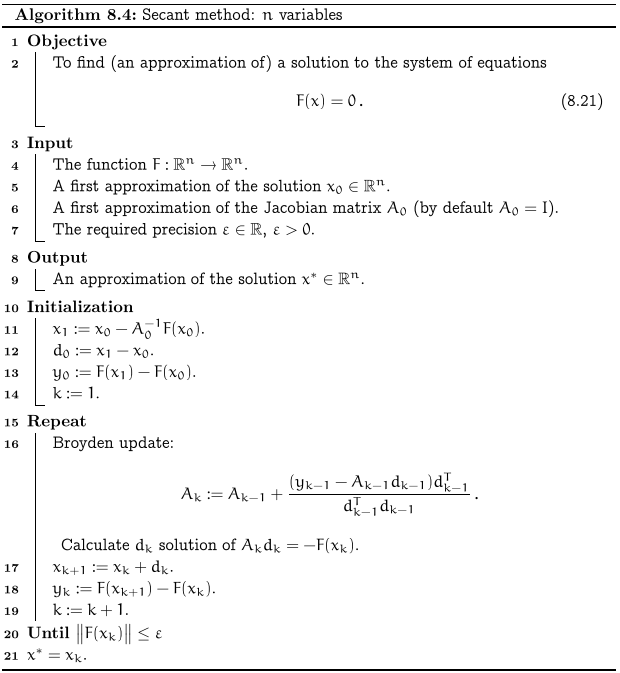

Example 7.11: $F(x)=\left(\begin{array}{c}(x_1+1)^2+ x_2^2 - 2 \\ e^{x_1} + x_2^3 - 2 \end{array}\right)$, $x_0=\left(\begin{array}{c} 1 \\ 1 \end{array}\right)$


  k                 x1                 x2           ||F(x)||
  1  -2.0000000000E+00  -7.1828182846E-01  +2.2870623161E+00
  2  -1.6645002598E+00  +8.3092159564E-01  +1.5111783668E+00
  3  -2.4256256405E-01  +2.0377121351E+00  +7.7415651325E+00
  4  -1.2415558219E+00  +7.7129132903E-01  +1.8389803017E+00
  5  -5.8052166843E-01  +4.2221178143E-01  +2.1382593322E+00
  6  -3.2619320912E+00  +2.0382595967E+00  +9.7568758204E+00
  7  -1.1090527427E+00  +7.0750961204E-01  +1.9860884230E+00
  8  -1.4790623218E+00  +9.3139007890E-01  +1.3210119220E+00
  9  -1.8328702355E+00  +1.2782832855E+00  +4.1135888735E-01
 10  -1.7071565995E+00  +1.1909193465E+00  +1.5312998941E-01
 11  -1.7095278553E+00  +1.2145804348E+00  +3.4660464004E-02
 12  -1.7140015911E+00  +1.2217390421E+00  +4.4912891939E-03
 13  -1.7137755698E+00  +1.2209191235E+00  +1.8330906599E-04
 14  -1.7137453415E+00  +1.2208840186E+00  +1.5620863849E-05
 15  -1.7137473875E+00  +1.2208867888E+00  +1.8542288538E-07
 16  -1.7137474114E+00  

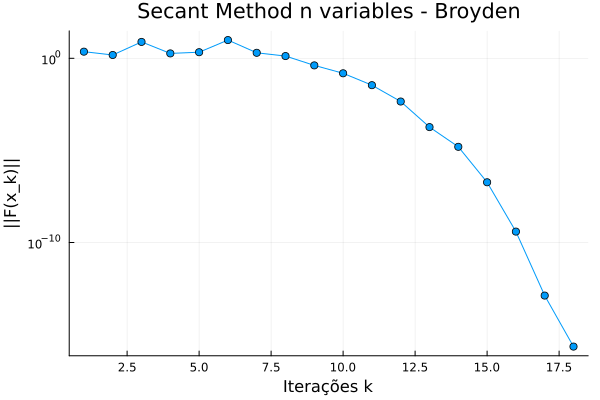

In [10]:
F(x) = [
    (x[1] + 1)^2 + x[2]^2 - 2
    exp(x[1]) + x[2]^3 - 2
]

x = [1.0, 1.0]
epsilon = 1e-15
maxiter = 50

A = Matrix{Float64}(I, 2, 2)

# Initialization
x_new = x - A \ F(x)
d = x_new - x
y = F(x_new) - F(x)

x = x_new
k = 1

ks = Int[]
norms = Float64[]

@printf("%3s %18s %18s %18s\n", "k", "x1", "x2", "||F(x)||")

while k <= maxiter
    Fx = F(x)
    normFx = norm(Fx)

    push!(ks, k)
    push!(norms, max(normFx, 1e-16))

    @printf("%3d %+18.10E %+18.10E %+18.10E\n", k, x[1], x[2], normFx)

    if normFx <= epsilon
        break
    end

    # Broyden update
    A = A + ((y - A*d) * d') / (d' * d)

    # Solve A_k d_k = -F(x_k)
    d = A \ (-Fx)

    x_old = x
    x = x + d

    y = F(x) - F(x_old)

    k += 1
end

println("\nSolução aproximada:")
println("x* = ", x)
println("F(x*) = ", F(x))
println("||F(x*)|| = ", norm(F(x)))

plot(
    ks,
    norms,
    marker = :circle,
    xlabel = "Iterações k",
    ylabel = "||F(x_k)||",
    title = "Secant Method n variables - Broyden",
    legend = false,
    yscale = :log10
)